In [ ]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv("insurance2.csv")

In [ ]:
df_encoded = pd.read_csv("insurance2.csv")

In [ ]:

# Sex
df['sex'] = df['sex'].replace({
    0: 'Female',
    1: 'Male'
})

# Smoker
df['smoker'] = df['smoker'].replace({
    0: 'Not Smoking',
    1: 'Smoking'
})

# Region
df['region'] = df['region'].replace({
    0: 'Northeast',
    1: 'Northwest',
    2: 'Southeast',
    3: 'Southwest'
})

# Insurance Claim
df['insuranceclaim'] = df['insuranceclaim'].replace({
    0: 'No Claim',
    1: 'Claim'
})

In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges,insuranceclaim
0,19,Female,27.900,0,Smoking,Southwest,16884.92400,Claim
1,18,Male,33.770,1,Not Smoking,Southeast,1725.55230,Claim
2,28,Male,33.000,3,Not Smoking,Southeast,4449.46200,No Claim
3,33,Male,22.705,0,Not Smoking,Northwest,21984.47061,No Claim
4,32,Male,28.880,0,Not Smoking,Northwest,3866.85520,Claim


In [ ]:
df.shape

(1338, 8)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             1338 non-null   int64  
 1   sex             1338 non-null   object 
 2   bmi             1338 non-null   float64
 3   children        1338 non-null   int64  
 4   smoker          1338 non-null   object 
 5   region          1338 non-null   object 
 6   charges         1338 non-null   float64
 7   insuranceclaim  1338 non-null   object 
dtypes: float64(2), int64(2), object(4)
memory usage: 83.8+ KB


In [ ]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0
insuranceclaim,0


In [ ]:
df.duplicated().sum()

np.int64(1)

In [ ]:
df = df.drop_duplicates()

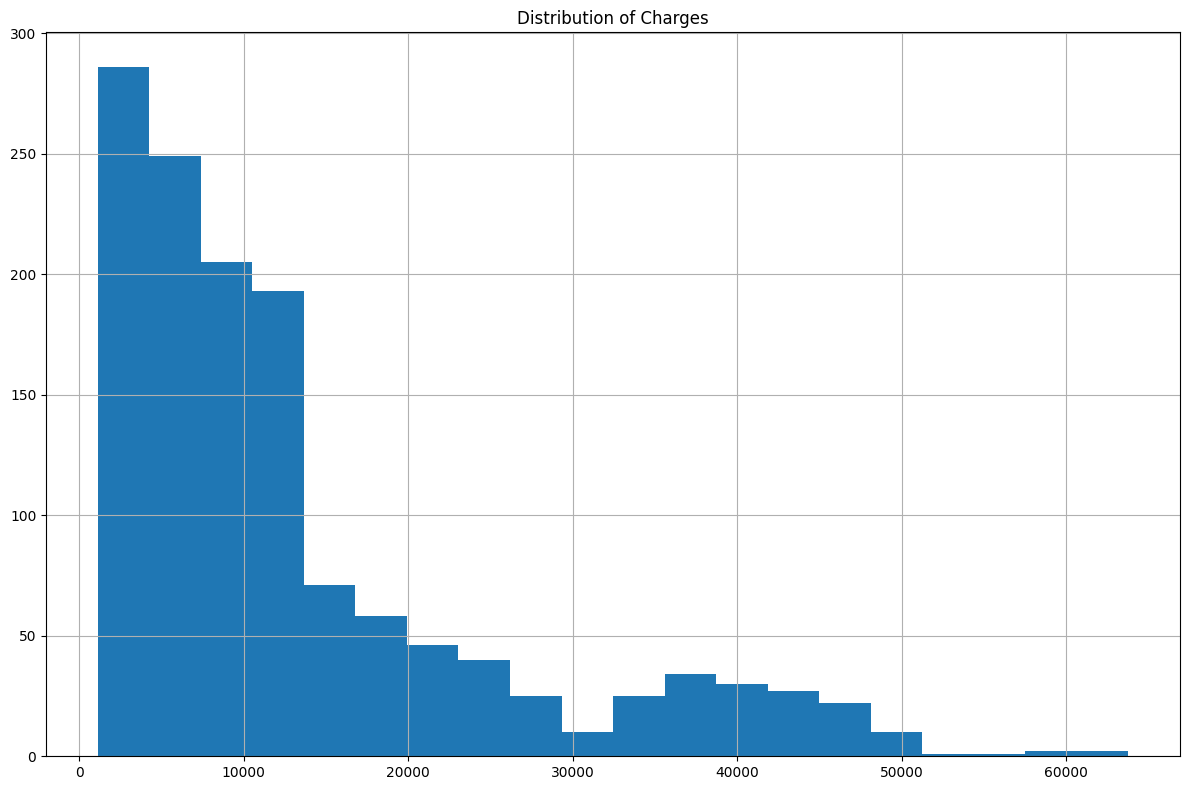

In [ ]:
df['charges'].hist(bins=20)

plt.gcf().set_size_inches(12, 8)
plt.title('Distribution of Charges')
plt.tight_layout()
plt.show()

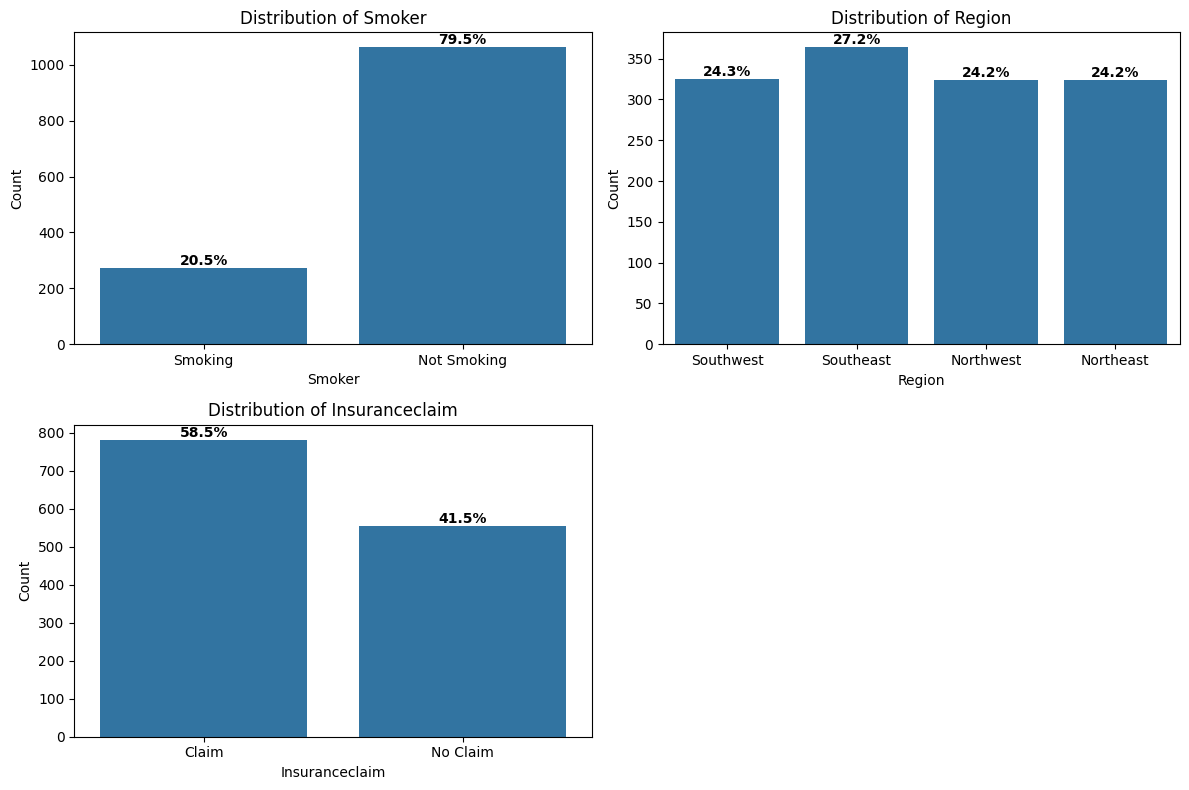

In [ ]:
categorical_cols = [ 'smoker', 'region', 'insuranceclaim']

plt.figure(figsize=(12,8))

for i, col in enumerate(categorical_cols):

    plt.subplot(2,2,i+1)

    ax = sns.countplot(x=df[col])

    # Total observations
    total = len(df[col])

    # Add percentage labels
    for p in ax.patches:

        percentage = 100 * p.get_height() / total

        ax.annotate(
            f'{percentage:.1f}%',
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold',
            color='black'
        )

    plt.title(f'Distribution of {col.capitalize()}')

    plt.ylabel('Count')
    plt.xlabel(col.capitalize())

plt.tight_layout()
plt.show()

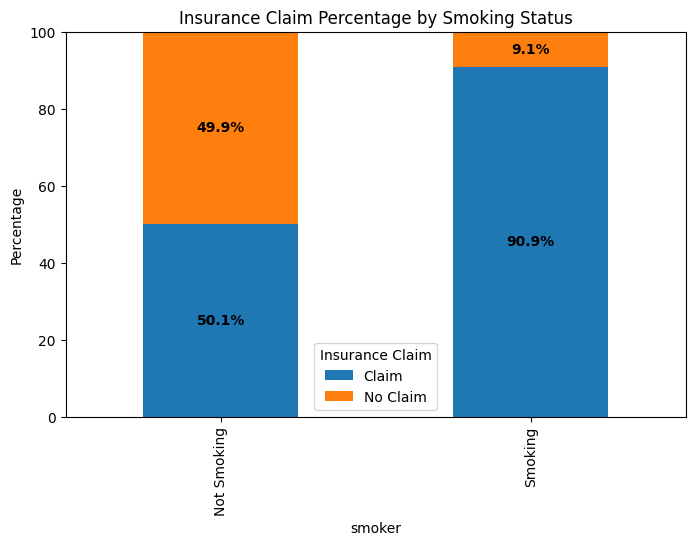

In [ ]:
smoker_claim = pd.crosstab(
    df['smoker'],
    df['insuranceclaim'],
    normalize='index'
) * 100

ax = smoker_claim.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

# Add percentage labels
for container in ax.containers:

    labels = [f'{v:.1f}%' if v > 0 else '' for v in container.datavalues]

    ax.bar_label(
        container,
        labels=labels,
        label_type='center',
        fontsize=10,
        color='black',
        fontweight='bold'
    )

plt.title('Insurance Claim Percentage by Smoking Status')

plt.ylabel('Percentage')

plt.ylim(0,100)

plt.legend(title='Insurance Claim')

plt.show()

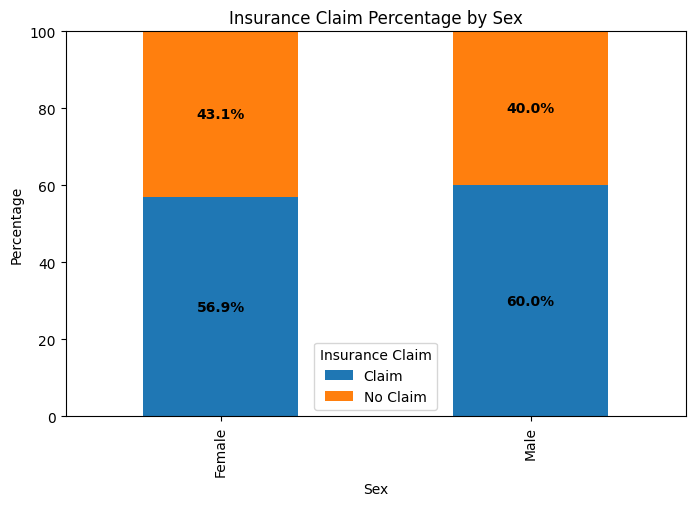

In [ ]:
sex_claim = pd.crosstab(
    df['sex'],
    df['insuranceclaim'],
    normalize='index'
) * 100

ax = sex_claim.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

for container in ax.containers:

    labels = [f'{v:.1f}%' if v > 0 else '' for v in container.datavalues]

    ax.bar_label(
        container,
        labels=labels,
        label_type='center',
        fontsize=10,
        color='black',
        fontweight='bold'
    )

plt.title('Insurance Claim Percentage by Sex')

plt.ylabel('Percentage')

plt.xlabel('Sex')

plt.ylim(0,100)

plt.legend(title='Insurance Claim')

plt.show()

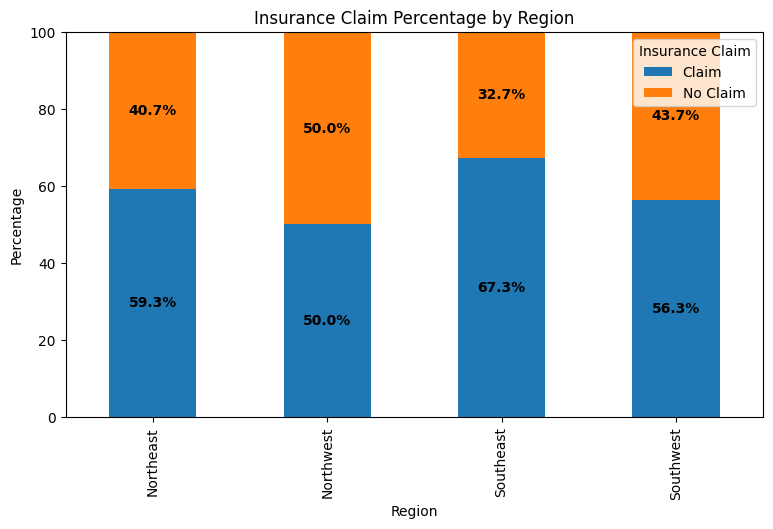

In [ ]:
region_claim = pd.crosstab(
    df['region'],
    df['insuranceclaim'],
    normalize='index'
) * 100

ax = region_claim.plot(
    kind='bar',
    stacked=True,
    figsize=(9,5)
)

for container in ax.containers:

    labels = [f'{v:.1f}%' if v > 0 else '' for v in container.datavalues]

    ax.bar_label(
        container,
        labels=labels,
        label_type='center',
        fontsize=10,
        color='black',
        fontweight='bold'
    )

plt.title('Insurance Claim Percentage by Region')

plt.ylabel('Percentage')

plt.xlabel('Region')

plt.ylim(0,100)

plt.legend(title='Insurance Claim')

plt.show()

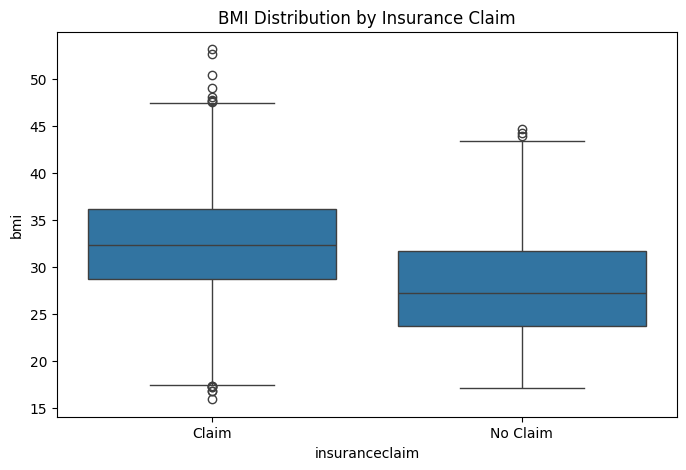

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='insuranceclaim',
    y='bmi',
    data=df
)

plt.title('BMI Distribution by Insurance Claim')

plt.show()

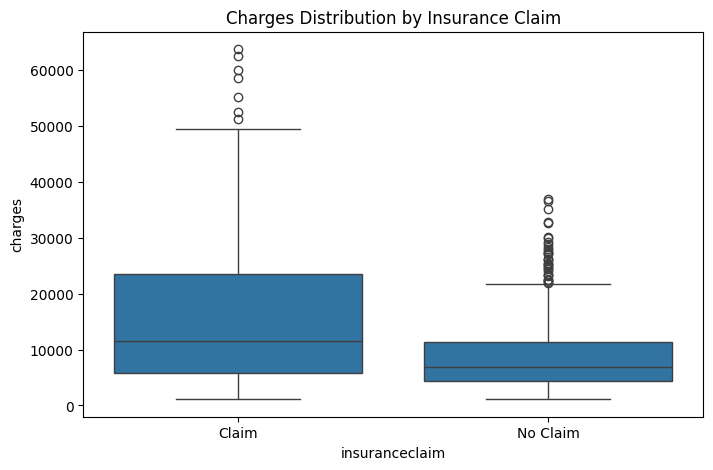

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='insuranceclaim',
    y='charges',
    data=df
)

plt.title('Charges Distribution by Insurance Claim')

plt.show()

In [ ]:
from scipy.stats import shapiro

claim_yes_bmi = df_encoded[df_encoded['insuranceclaim'] == 1]['bmi']

claim_no_bmi = df_encoded[df_encoded['insuranceclaim'] == 0]['bmi']

print(shapiro(claim_yes_bmi))
print(shapiro(claim_no_bmi))

ShapiroResult(statistic=np.float64(0.9922949446132323), pvalue=np.float64(0.0004344171803840097))
ShapiroResult(statistic=np.float64(0.9729179897238167), pvalue=np.float64(1.3243309383861967e-08))


In [ ]:
from scipy.stats import shapiro

claim_yes_charges = df_encoded[df_encoded['insuranceclaim'] == 1]['charges']

claim_no_charges = df_encoded[df_encoded['insuranceclaim'] == 0]['charges']

print(shapiro(claim_yes_charges))
print(shapiro(claim_no_charges))

ShapiroResult(statistic=np.float64(0.8645576502937047), pvalue=np.float64(1.9416759156866585e-25))
ShapiroResult(statistic=np.float64(0.8494858545169038), pvalue=np.float64(1.428062393188244e-22))


In [ ]:
from scipy.stats import shapiro

claim_yes_age = df_encoded[df_encoded['insuranceclaim'] == 1]['age']

claim_no_age = df_encoded[df_encoded['insuranceclaim'] == 0]['age']

print(shapiro(claim_yes_age))
print(shapiro(claim_no_age))

ShapiroResult(statistic=np.float64(0.927382330090049), pvalue=np.float64(5.274987021450468e-19))
ShapiroResult(statistic=np.float64(0.9573930554046155), pvalue=np.float64(1.3917488295377508e-11))


In [ ]:
from scipy.stats import shapiro

claim_yes = df_encoded[df_encoded['insuranceclaim'] == 1]['children']

claim_no = df_encoded[df_encoded['insuranceclaim'] == 0]['children']

print(shapiro(claim_yes))
print(shapiro(claim_no))

ShapiroResult(statistic=np.float64(0.7140001359139532), pvalue=np.float64(1.769576032727527e-34))
ShapiroResult(statistic=np.float64(0.9102271853384702), pvalue=np.float64(1.3662293113690904e-17))


In [ ]:
from scipy.stats import mannwhitneyu

stat, p = mannwhitneyu(
    claim_yes_bmi,
    claim_no_bmi
)

print("Statistic:", stat)
print("P-value:", p)

Statistic: 318602.0
P-value: 5.831855158138455e-48


In [ ]:
from scipy.stats import mannwhitneyu

stat, p = mannwhitneyu(
    claim_yes_age,
    claim_no_age
)

print("Statistic:", stat)
print("P-value:", p)

Statistic: 245138.5
P-value: 6.294707075537323e-05


In [ ]:
from scipy.stats import mannwhitneyu

stat, p = mannwhitneyu(
    claim_yes_charges,
    claim_no_charges
)

print("Statistic:", stat)
print("P-value:", p)

Statistic: 282433.0
P-value: 8.286037438810306e-21


In [ ]:
from scipy.stats import mannwhitneyu

stat, p = mannwhitneyu(
    claim_yes,
    claim_no
)

print("Statistic:", stat)
print("P-value:", p)

Statistic: 114645.0
P-value: 1.822079115703687e-54


## Global Machine Learning Model

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder # Import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# Define features (X) and target (y) using the deduplicated 'df'
# 'df' comes from 37dfd005, where 'sex' and 'smoker' are boolean and 'region' is int64
X = df.drop('insuranceclaim', axis=1).copy() # Ensure copy
y = df['insuranceclaim'] # Target is already numerical 0/1

# Identify features for different encoding strategies
ordinal_features = ['sex', 'smoker']
onehot_features = ['region']
numerical_features = ['age', 'bmi', 'children', 'charges']

# Get unique categories for one-hot encoded features (region is int64 in X)
region_categories = sorted(X['region'].unique()) # e.g., [0, 1, 2, 3]

# Create preprocessing transformers
numerical_transformer = StandardScaler()
# OrdinalEncoder for boolean features (sex, smoker). It will map False -> 0, True -> 1 (or vice versa depending on sort).
ordinal_transformer = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
# OneHotEncoder for integer region feature. Explicit categories ensure consistency.
onehot_transformer = OneHotEncoder(
    handle_unknown='ignore',
    drop=None,
    categories=[region_categories] # Explicitly define categories for region (e.g., [0, 1, 2, 3])
)

# Create a column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('ord', ordinal_transformer, ordinal_features),
        ('ohe', onehot_transformer, onehot_features)
    ],
    remainder='passthrough' # Keep any other columns if they exist
)

# Create a pipeline with preprocessing and a Gradient Boosting Classifier
model_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('classifier', GradientBoostingClassifier(random_state=42))])

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train the model
model_pipeline.fit(X_train, y_train)

# Store y_prob for the global GradientBoosting model for later use in cell 3ede7563
y_prob_global_gbc = model_pipeline.predict_proba(X_test)[:, 1]

print("Global model trained successfully with updated encoding strategy (Ordinal for sex/smoker, OneHot for region)!")

Global model trained successfully with updated encoding strategy (Ordinal for sex/smoker, OneHot for region)!


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# Make predictions on the test set
y_pred = model_pipeline.predict(X_test)
y_prob = model_pipeline.predict_proba(X_test)[:, 1] # Probability of the positive class (claim)

# Evaluate the model
print("### Model Evaluation (Global Model) ###")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, pos_label='Claim'):.4f}")
print(f"Recall: {recall_score(y_test, y_pred, pos_label='Claim'):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred, pos_label='Claim'):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

print("\nConfusion Matrix:")
display(pd.DataFrame(confusion_matrix(y_test, y_pred, labels=['No Claim', 'Claim']), index=['Actual No Claim', 'Actual Claim'], columns=['Predicted No Claim', 'Predicted Claim']))


print("\nClassification Report:")
print(classification_report(y_test, y_pred, labels=['No Claim', 'Claim']))

### Model Evaluation (Global Model) ###
Accuracy: 0.9888
Precision: 0.9936
Recall: 0.9873
F1-Score: 0.9904
ROC AUC Score: 0.9961

Confusion Matrix:


,Predicted No Claim,Predicted Claim
Actual No Claim,110,1
Actual Claim,2,155



Classification Report:
              precision    recall  f1-score   support

    No Claim       0.98      0.99      0.99       111
       Claim       0.99      0.99      0.99       157

    accuracy                           0.99       268
   macro avg       0.99      0.99      0.99       268
weighted avg       0.99      0.99      0.99       268



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier # Added KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier # Explicitly import, though already in a539ad73

# Initialize models
logistic_model = LogisticRegression(random_state=42, solver='liblinear')
knn_model = KNeighborsClassifier() # Replaced XGBoost with KNeighborsClassifier
svm_model = SVC(random_state=42, probability=True) # probability=True for ROC AUC score

# Dictionary to store new models
additional_global_models = {
    'Logistic Regression': logistic_model,
    'KNeighbors': knn_model, # Changed model name
    'SVM': svm_model
}

# Dictionary to store metrics for new models
additional_global_metrics = {}

# Iterate through and train/evaluate each new model
for model_name, model in additional_global_models.items():
    print(f"\n--- Training and Evaluating Global {model_name} Model ---")

    # Create a pipeline with preprocessing and the current model
    model_pipeline_new = Pipeline(steps=[('preprocessor', preprocessor),
                                         ('classifier', model)])

    # Train the model (y_train is now numerical 0/1)
    model_pipeline_new.fit(X_train, y_train)

    # Make predictions
    y_pred_new = model_pipeline_new.predict(X_test)
    y_prob_new = model_pipeline_new.predict_proba(X_test)[:, 1]

    y_train_pred_new = model_pipeline_new.predict(X_train)

    # Calculate metrics (y_test and predictions are numerical 0/1)
    accuracy_test = accuracy_score(y_test, y_pred_new)
    accuracy_train = accuracy_score(y_train, y_train_pred_new)
    precision = precision_score(y_test, y_pred_new, pos_label='Claim')
    recall = recall_score(y_test, y_pred_new, pos_label='Claim')
    f1 = f1_score(y_test, y_pred_new, pos_label='Claim')
    roc_auc = roc_auc_score(y_test, y_prob_new)

    additional_global_metrics[model_name] = {
        'accuracy_train': accuracy_train,
        'accuracy_test': accuracy_test,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'roc_auc_score': roc_auc
    }

    print(f"Training Accuracy: {accuracy_train:.4f}")
    print(f"Testing Accuracy: {accuracy_test:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"ROC AUC Score: {roc_auc:.4f}")

print("\n--- Consolidated Global Model Performance Comparison ---")

# Recalculate global_metrics to include training accuracy for GradientBoosting
# model_pipeline (GradientBoosting) was trained with numerical y_train in a539ad73
predictions_train_gbc = model_pipeline.predict(X_train)
y_pred_gbc = model_pipeline.predict(X_test)

global_metrics_gbc = {
    'accuracy_train': accuracy_score(y_train, predictions_train_gbc),
    'accuracy_test': accuracy_score(y_test, y_pred_gbc),
    'precision': precision_score(y_test, y_pred_gbc, pos_label='Claim'),
    'recall': recall_score(y_test, y_pred_gbc, pos_label='Claim'),
    'f1_score': f1_score(y_test, y_pred_gbc, pos_label='Claim'),
    'roc_auc_score': roc_auc_score(y_test, y_prob_global_gbc) # Use y_prob from cell a539ad73
}

# Combine all global model metrics
all_global_models_metrics = {
    'GradientBoosting (Global)': global_metrics_gbc # Changed model name
}
all_global_models_metrics.update(additional_global_metrics)

consolidated_comparison_df = pd.DataFrame.from_dict(all_global_models_metrics, orient='index')

display(consolidated_comparison_df.round(4))


--- Training and Evaluating Global Logistic Regression Model ---
Training Accuracy: 0.8793
Testing Accuracy: 0.8657
Precision: 0.8623
Recall: 0.9172
F1-Score: 0.8889
ROC AUC Score: 0.9204

--- Training and Evaluating Global KNeighbors Model ---
Training Accuracy: 0.9289
Testing Accuracy: 0.8806
Precision: 0.9032
Recall: 0.8917
F1-Score: 0.8974
ROC AUC Score: 0.9436

--- Training and Evaluating Global SVM Model ---
Training Accuracy: 0.9205
Testing Accuracy: 0.9067
Precision: 0.9342
Recall: 0.9045
F1-Score: 0.9191
ROC AUC Score: 0.9540

--- Consolidated Global Model Performance Comparison ---


,accuracy_train,accuracy_test,precision,recall,f1_score,roc_auc_score
GradientBoosting (Global),0.9944,0.9888,0.9936,0.9873,0.9904,0.9961
Logistic Regression,0.8793,0.8657,0.8623,0.9172,0.8889,0.9204
KNeighbors,0.9289,0.8806,0.9032,0.8917,0.8974,0.9436
SVM,0.9205,0.9067,0.9342,0.9045,0.9191,0.9540


## Hierarchical Clustering (Agglomerative Clustering)

Feature Matrix Shape: (1337, 7)

Computing Gower Distance Matrix...
Gower Distance Matrix Shape: (1337, 1337)
Distance Range: 0.0 to 0.8857


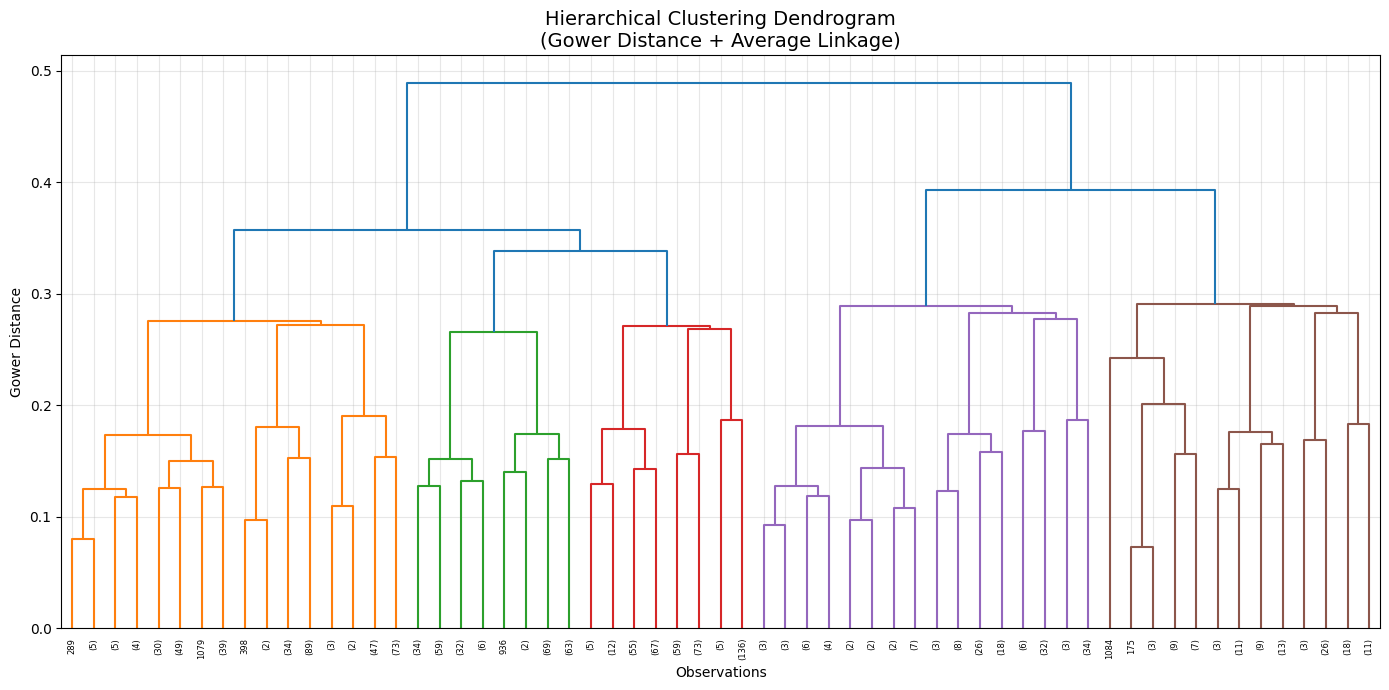


Silhouette Scores:

k = 2 --> Silhouette Score = 0.3683
k = 3 --> Silhouette Score = 0.2865
k = 4 --> Silhouette Score = 0.2882
k = 5 --> Silhouette Score = 0.3315
k = 6 --> Silhouette Score = 0.3095
k = 7 --> Silhouette Score = 0.3024
k = 8 --> Silhouette Score = 0.3069
k = 9 --> Silhouette Score = 0.3180
k = 10 --> Silhouette Score = 0.3190


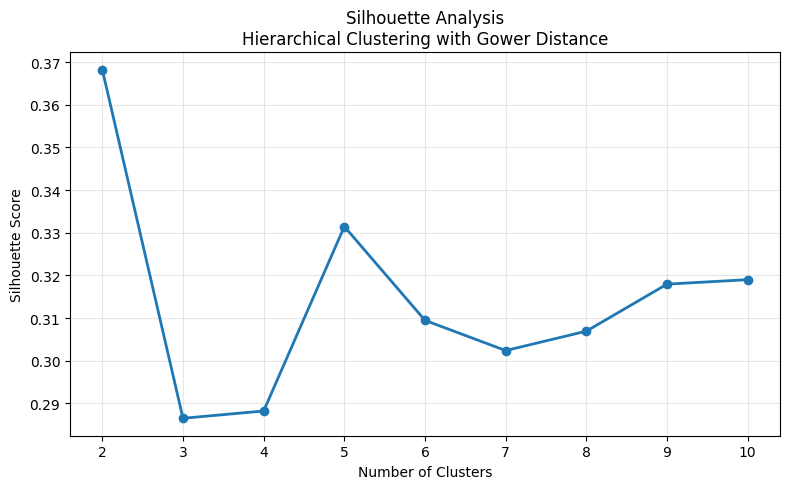


Best Number of Clusters: 2

Cluster Distribution:

Cluster
0    1063
1     274
Name: count, dtype: int64

Cluster Means:

           age    bmi  children   charges
Cluster                                  
0        39.40  30.65      1.09   8440.66
1        38.51  30.71      1.11  32050.23

Sex Distribution (%):

sex      False  True 
Cluster              
0        51.46  48.54
1        41.97  58.03

Smoker Distribution (%):

smoker   False  True 
Cluster              
0        100.0    0.0
1          0.0  100.0

Region Distribution (%):

region       0      1      2      3
Cluster                            
0        24.18  25.02  25.68  25.12
1        24.45  21.17  33.21  21.17

Insurance Claim Distribution (%):

insuranceclaim  Claim  No Claim
Cluster                        
0               50.14     49.86
1               90.88      9.12

Explained Variance Ratio:
[0.28418968 0.19313346]

Total Variance Explained: 0.4773


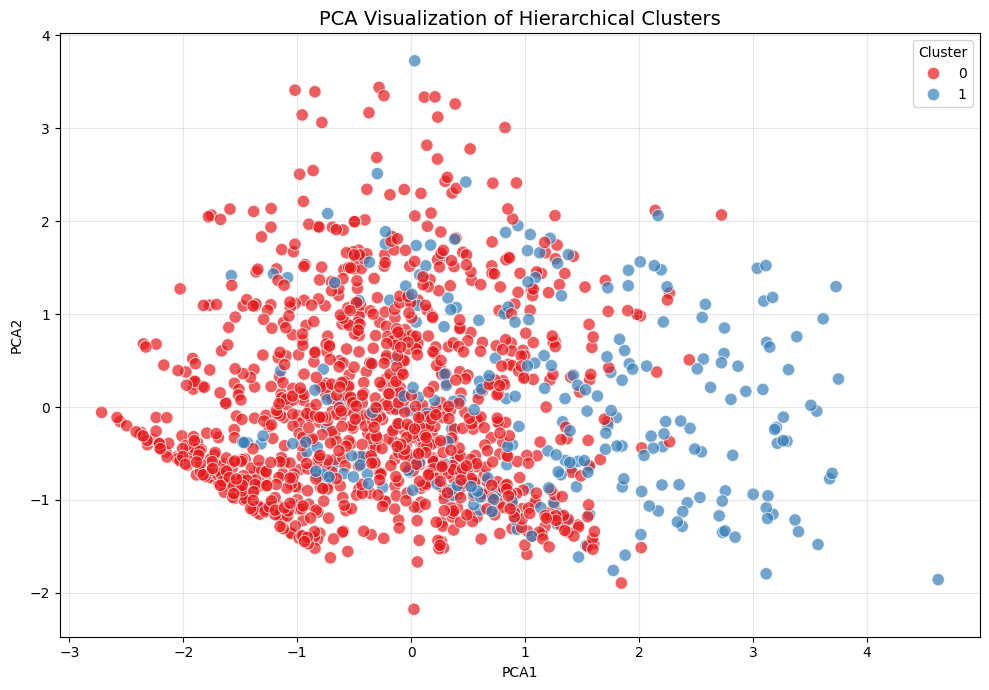

In [ ]:
# =========================================================
# HIERARCHICAL CLUSTERING USING GOWER DISTANCE
# FOR MIXED NUMERICAL + CATEGORICAL DATA
# =========================================================

!pip install gower

import pandas as pd
import numpy as np
import gower
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
from sklearn.metrics import silhouette_score



import warnings
warnings.filterwarnings('ignore')

# =========================================================
# LOAD DATA
# =========================================================

df = pd.read_csv('insurance2.csv')
# Change sex and smoker to True/False
df['sex'] = df['sex'].astype(bool)
df['smoker'] = df['smoker'].astype(bool)
# Returns a new DataFrame with duplicates removed
df = df.drop_duplicates()

# Convert 'insuranceclaim' to string labels for consistency
df['insuranceclaim'] = df['insuranceclaim'].replace({
    0: 'No Claim',
    1: 'Claim'
})

# =========================================================
# DEFINE VARIABLES
# =========================================================

# Target variable
target = 'insuranceclaim'

# Numerical variables
# (Recommended: exclude charges from clustering)
numerical_cols = ['age', 'bmi', 'children','charges']


# Categorical variables
categorical_cols = ['sex', 'region','smoker']


# =========================================================
# PREPARE DATA
# =========================================================

# Create feature matrix
X = df[numerical_cols + categorical_cols].copy()

# Convert categorical variables to string
# This ensures Gower treats them as categorical

for col in categorical_cols:
    X[col] = X[col].astype(str)

print("Feature Matrix Shape:", X.shape)

# =========================================================
# SPECIFY CATEGORICAL FEATURES
# =========================================================

# False = numerical
# True  = categorical

cat_features = [
    False,
     False, # age
    False,  # bmi
    False,  # children
    True,   # sex
      True, # smoker
    True    # region
]

# =========================================================
# COMPUTE GOWER DISTANCE MATRIX
# =========================================================

print("\nComputing Gower Distance Matrix...")

gower_dist = gower.gower_matrix(
    X,
    cat_features=cat_features
)

print("Gower Distance Matrix Shape:", gower_dist.shape)

print("Distance Range:",
      round(gower_dist.min(), 4),
      "to",
      round(gower_dist.max(), 4))

# =========================================================
# CONVERT TO CONDENSED DISTANCE MATRIX
# =========================================================

# linkage() requires condensed form

condensed_dist = squareform(
    gower_dist,
    checks=False
)

# =========================================================
# HIERARCHICAL CLUSTERING
# =========================================================

# Use average linkage
# (Correct for Gower distance)

linked = linkage(
    condensed_dist,
    method='average'
)

# =========================================================
# DENDROGRAM
# =========================================================

plt.figure(figsize=(14, 7))

dendrogram(
    linked,
    truncate_mode='level',
    p=5,
    color_threshold=0.3
)

plt.title(
    'Hierarchical Clustering Dendrogram\n(Gower Distance + Average Linkage)',
    fontsize=14
)

plt.xlabel('Observations')
plt.ylabel('Gower Distance')

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# =========================================================
# SILHOUETTE ANALYSIS
# =========================================================

silhouette_scores = []

K_range = range(2, 11)

print("\nSilhouette Scores:\n")

for k in K_range:

    labels = fcluster(
        linked,
        k,
        criterion='maxclust'
    )

    score = silhouette_score(
        gower_dist,
        labels,
        metric='precomputed'
    )

    silhouette_scores.append(score)

    print(f"k = {k} --> Silhouette Score = {score:.4f}")

# =========================================================
# PLOT SILHOUETTE SCORES
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    K_range,
    silhouette_scores,
    marker='o',
    linewidth=2
)

plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')

plt.title(
    'Silhouette Analysis\nHierarchical Clustering with Gower Distance'
)

plt.xticks(K_range)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# =========================================================
# BEST NUMBER OF CLUSTERS
# =========================================================

best_k = K_range[np.argmax(silhouette_scores)]

print("\nBest Number of Clusters:", best_k)

# =========================================================
# ASSIGN FINAL CLUSTERS
# =========================================================

df['Cluster'] = fcluster(
    linked,
    best_k,
    criterion='maxclust'
) - 1

# =========================================================
# CLUSTER DISTRIBUTION
# =========================================================

print("\nCluster Distribution:\n")

print(df['Cluster'].value_counts())

# =========================================================
# NUMERICAL VARIABLE PROFILE
# =========================================================

print("\nCluster Means:\n")

print(
    df.groupby('Cluster')[
        ['age', 'bmi', 'children', 'charges']
    ].mean().round(2)
)

# =========================================================
# CATEGORICAL VARIABLE PROFILE
# =========================================================

print("\nSex Distribution (%):\n")

sex_profile = pd.crosstab(
    df['Cluster'],
    df['sex'],
    normalize='index'
) * 100

print(sex_profile.round(2))

# ---------------------------------------------------------

print("\nSmoker Distribution (%):\n")

smoker_profile = pd.crosstab(
    df['Cluster'],
    df['smoker'],
    normalize='index'
) * 100

print(smoker_profile.round(2))

# ---------------------------------------------------------

print("\nRegion Distribution (%):\n")

region_profile = pd.crosstab(
    df['Cluster'],
    df['region'],
    normalize='index'
) * 100

print(region_profile.round(2))

# ---------------------------------------------------------

print("\nInsurance Claim Distribution (%):\n")

claim_profile = pd.crosstab(
    df['Cluster'],
    df['insuranceclaim'],
    normalize='index'
) * 100

print(claim_profile.round(2))

# =========================================================
# OPTIONAL: PCA VISUALIZATION
# =========================================================

# PCA is ONLY for visualization
# NOT for clustering itself

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA

preprocessor = ColumnTransformer(
    transformers=[

        ('num',
         StandardScaler(),
         numerical_cols),

        ('cat',
         OneHotEncoder(drop='if_binary'),
         categorical_cols)
    ]
)

X_pca_ready = preprocessor.fit_transform(
    df[numerical_cols + categorical_cols]
)

# PCA
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_pca_ready)

df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

print("\nExplained Variance Ratio:")

print(pca.explained_variance_ratio_)

print("\nTotal Variance Explained:",
      round(pca.explained_variance_ratio_.sum(), 4))

# =========================================================
# PCA CLUSTER VISUALIZATION
# =========================================================

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    palette='Set1',
    s=80,
    alpha=0.7
)

plt.title(
    'PCA Visualization of Hierarchical Clusters',
    fontsize=14
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.manifold import MDS

mds = MDS(
    n_components=2,
    dissimilarity='precomputed',
    random_state=42
)

X_mds = mds.fit_transform(gower_dist)

df['MDS1'] = X_mds[:,0]
df['MDS2'] = X_mds[:,1]

<Axes: xlabel='MDS1', ylabel='MDS2'>

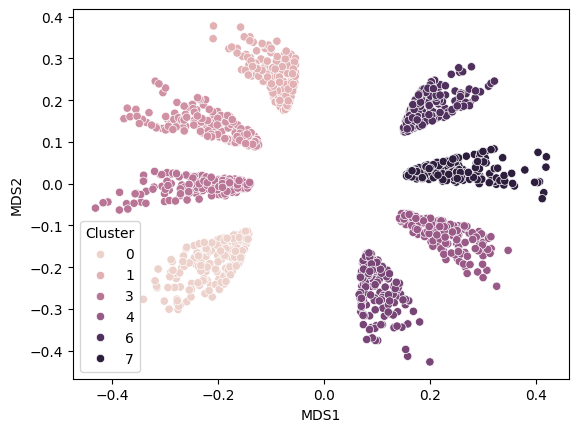

In [ ]:
sns.scatterplot(
    x='MDS1',
    y='MDS2',
    hue='Cluster',
    data=df
)

For Hierarchical Clustering, determining the 'optimal' number of clusters often involves inspecting a dendrogram. However, for a direct comparison with K-Means and K-Prototypes, we can start by setting `n_clusters` to a similar value (e.g., 3) and then analyze the results. If a dendrogram is desired, it would involve calculating a linkage matrix first.

In [ ]:
print("\n--- K-Fold Cross-Validation for Hierarchical Cluster Models (All Classifiers) ---")

cluster_cv_results = {}

from sklearn.base import clone # Import clone
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import GradientBoostingClassifier # Changed from RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier # Added KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder # Add OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def run_kfold_cv(model_pipeline, X, y, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    # Lists to store metrics for each fold
    train_accuracies = []
    test_accuracies = []
    precisions = []
    recalls = []
    f1_scores = []
    roc_aucs = []

    print(f"Running {n_splits}-fold cross-validation...")

    for fold, (train_index, test_index) in enumerate(skf.split(X, y)):
        # Create fresh copies of the pipeline for each fold
        model_pipeline_clone = clone(model_pipeline)

        X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
        y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

        # Train the model for the current fold
        model_pipeline_clone.fit(X_train_fold, y_train_fold)

        # Make predictions for training and testing sets
        y_train_pred = model_pipeline_clone.predict(X_train_fold)
        y_test_pred = model_pipeline_clone.predict(X_test_fold)
        y_test_prob = model_pipeline_clone.predict_proba(X_test_fold)[:, 1]

        # Calculate metrics for the current fold
        train_accuracies.append(accuracy_score(y_train_fold, y_train_pred))
        test_accuracies.append(accuracy_score(y_test_fold, y_test_pred))
        precisions.append(precision_score(y_test_fold, y_test_pred, pos_label='Claim', zero_division=0))
        recalls.append(recall_score(y_test_fold, y_test_pred, pos_label='Claim', zero_division=0))
        f1_scores.append(f1_score(y_test_fold, y_test_pred, pos_label='Claim', zero_division=0))
        roc_aucs.append(roc_auc_score(y_test_fold, y_test_prob))

    # Calculate average metrics
    avg_metrics = {
        'accuracy_train_avg': np.mean(train_accuracies),
        'accuracy_test_avg': np.mean(test_accuracies),
        'precision_avg': np.mean(precisions),
        'recall_avg': np.mean(recalls),
        'f1_score_avg': np.mean(f1_scores),
        'roc_auc_score_avg': np.mean(roc_aucs)
    }

    return avg_metrics

# --- Start of Global Model K-Fold Cross-Validation ---
# The global preprocessor 'preprocessor' is now defined in a539ad73 with the new encoding.
# It will be used here implicitly by model_pipeline_new in the loop below.

# GradientBoosting Pipeline (replaces RandomForest)
gbc_pipeline_cv = Pipeline(steps=[('preprocessor', preprocessor),
                               ('classifier', GradientBoostingClassifier(random_state=42))])

# Logistic Regression Pipeline
logreg_pipeline_cv = Pipeline(steps=[('preprocessor', preprocessor),
                                   ('classifier', LogisticRegression(random_state=42, solver='liblinear'))])

# KNeighbors Pipeline (replaces XGBoost)
knn_pipeline_cv = Pipeline(steps=[('preprocessor', preprocessor),
                                ('classifier', KNeighborsClassifier())])

# SVM Pipeline
svm_pipeline_cv = Pipeline(steps=[('preprocessor', preprocessor),
                                ('classifier', SVC(random_state=42, probability=True))])

all_cv_pipelines = {
    'GradientBoosting (CV)': gbc_pipeline_cv, # Changed model name
    'Logistic Regression (CV)': logreg_pipeline_cv,
    'KNeighbors (CV)': knn_pipeline_cv, # Changed model name
    'SVM (CV)': svm_pipeline_cv
}

# Run K-fold CV for each global model
cv_results = {}
for model_name, pipeline in all_cv_pipelines.items():
    print(f"\n--- Running CV for {model_name} ---")
    cv_results[model_name] = run_kfold_cv(pipeline, X, y)

# Display consolidated global CV results
consolidated_cv_df = pd.DataFrame.from_dict(cv_results, orient='index')
print("\n--- Consolidated K-Fold Cross-Validation Results (Global Models) ---")
display(consolidated_cv_df.round(4))
# --- End of Global Model K-Fold Cross-Validation ---


# Now continue with the original logic for hierarchical cluster CV
for cluster_id in sorted(df['Cluster'].unique()):
    print(f"\n--- Running CV for Hierarchical Cluster {cluster_id} ---")

    # Filter data for the current cluster
    df_cluster = df[df['Cluster'] == cluster_id].copy()

    X_cluster = df_cluster.drop(['insuranceclaim', 'Cluster'], axis=1)
    y_cluster = df_cluster['insuranceclaim'] # Directly use the numerical column

    # Explicitly ensure categorical columns are of 'category' dtype if needed by a transformer
    # OrdinalEncoder and OneHotEncoder handle their assigned dtypes automatically
    # and X_cluster will have sex/smoker as bool, region as int64

    # Check if there's enough data to split and train
    if len(X_cluster) < 2: # Need at least 2 samples for train_test_split (or CV)
        print(f"Skipping Cluster {cluster_id}: Not enough data ({len(X_cluster)} samples).")
        continue

    # Check if there's only one class in y_cluster
    if len(y_cluster.unique()) < 2:
        print(f"Skipping Cluster {cluster_id}: Only one class present in target variable. Cannot perform stratified CV.")
        continue

    # Redefine the classifiers to be used for each cluster (copy from the earlier cell)
    classifiers = {
        'GradientBoosting': GradientBoostingClassifier(random_state=42), # Changed from RandomForest
        'LogisticRegression': LogisticRegression(random_state=42, solver='liblinear'),
        'KNeighbors': KNeighborsClassifier(), # Changed from XGBoost
        'SVM': SVC(random_state=42, probability=True) # probability=True for ROC AUC score
    }

    # Redefine preprocessor for clusters with the new encoding strategy
    cluster_numerical_features = ['age', 'bmi', 'children','charges']
    cluster_ordinal_features = ['sex', 'smoker']
    cluster_onehot_features = ['region']

    # Get unique categories for one-hot encoded features (region is int64 in X_cluster)
    # Using 'df' (full df) to ensure consistent categories across all models/clusters
    region_categories_cluster = sorted(df['region'].unique())

    preprocessor_for_clusters = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), cluster_numerical_features),
            ('ord', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cluster_ordinal_features),
            ('ohe', OneHotEncoder(handle_unknown='ignore', drop=None, categories=[region_categories_cluster]), cluster_onehot_features)
        ],
        remainder='passthrough'
    )

    for clf_name, clf in classifiers.items():
        print(f"  --- Running CV for {clf_name} in Cluster {cluster_id} ---")

        # Create a pipeline for the cluster model using the preprocessor_for_clusters
        model_pipeline_c_cv = Pipeline(steps=[('preprocessor', preprocessor_for_clusters),
                                           ('classifier', clone(clf))]) # Use clone to ensure fresh classifier instance

        # Run K-fold CV for the current cluster and classifier
        cv_results_for_this_combo = run_kfold_cv(model_pipeline_c_cv, X_cluster, y_cluster)

        # Rename keys to indicate it's a CV result for a cluster model
        renamed_results = {f'{key.replace("avg", "cv_avg") }': value for key, value in cv_results_for_this_combo.items()}

        cluster_cv_results[f'hca_cluster_{cluster_id}_{clf_name} (CV)'] = renamed_results

# Display consolidated cluster CV results
consolidated_cluster_cv_df = pd.DataFrame.from_dict(cluster_cv_results, orient='index')
print("\n--- Consolidated K-Fold Cross-Validation Results for Cluster Models ---")
display(consolidated_cluster_cv_df.round(4))

# Combine all CV results (global and cluster) for a final comparison
final_cv_comparison_df = pd.concat([consolidated_cv_df, consolidated_cluster_cv_df])
print("\n--- Final Consolidated K-Fold Cross-Validation Results (Global and Cluster Models) ---")
display(final_cv_comparison_df.round(4))


--- K-Fold Cross-Validation for Hierarchical Cluster Models (All Classifiers) ---

--- Running CV for GradientBoosting (CV) ---
Running 5-fold cross-validation...

--- Running CV for Logistic Regression (CV) ---
Running 5-fold cross-validation...

--- Running CV for KNeighbors (CV) ---
Running 5-fold cross-validation...

--- Running CV for SVM (CV) ---
Running 5-fold cross-validation...

--- Consolidated K-Fold Cross-Validation Results (Global Models) ---


,accuracy_train_avg,accuracy_test_avg,precision_avg,recall_avg,f1_score_avg,roc_auc_score_avg
GradientBoosting (CV),0.9931,0.9731,0.9799,0.9744,0.9769,0.9954
Logistic Regression (CV),0.8816,0.8803,0.8868,0.9117,0.8991,0.9221
KNeighbors (CV),0.9224,0.8744,0.8921,0.8939,0.8928,0.9424
SVM (CV),0.9231,0.8953,0.9398,0.8772,0.9073,0.9529



--- Running CV for Hierarchical Cluster 0 ---
  --- Running CV for GradientBoosting in Cluster 0 ---
Running 5-fold cross-validation...
  --- Running CV for LogisticRegression in Cluster 0 ---
Running 5-fold cross-validation...
  --- Running CV for KNeighbors in Cluster 0 ---
Running 5-fold cross-validation...
  --- Running CV for SVM in Cluster 0 ---
Running 5-fold cross-validation...

--- Running CV for Hierarchical Cluster 1 ---
  --- Running CV for GradientBoosting in Cluster 1 ---
Running 5-fold cross-validation...
  --- Running CV for LogisticRegression in Cluster 1 ---
Running 5-fold cross-validation...
  --- Running CV for KNeighbors in Cluster 1 ---
Running 5-fold cross-validation...
  --- Running CV for SVM in Cluster 1 ---
Running 5-fold cross-validation...

--- Consolidated K-Fold Cross-Validation Results for Cluster Models ---


,accuracy_train_cv_avg,accuracy_test_cv_avg,precision_cv_avg,recall_cv_avg,f1_score_cv_avg,roc_auc_score_cv_avg
hca_cluster_0_GradientBoosting (CV),0.9995,0.9812,0.9815,0.9813,0.9812,0.9970
hca_cluster_0_LogisticRegression (CV),0.8678,0.8655,0.8655,0.8743,0.8677,0.8948
hca_cluster_0_KNeighbors (CV),0.9139,0.8655,0.8733,0.8592,0.8649,0.9378
hca_cluster_0_SVM (CV),0.9095,0.8899,0.9389,0.8367,0.8837,0.9434
hca_cluster_1_GradientBoosting (CV),1.0000,0.9781,0.9803,0.9960,0.9881,0.9312
hca_cluster_1_LogisticRegression (CV),0.9808,0.9781,0.9765,1.0000,0.9881,0.9808
hca_cluster_1_KNeighbors (CV),0.9754,0.9672,0.9731,0.9919,0.9822,0.9744
hca_cluster_1_SVM (CV),0.9817,0.9745,0.9728,1.0000,0.9862,0.9872



--- Final Consolidated K-Fold Cross-Validation Results (Global and Cluster Models) ---


,accuracy_train_avg,accuracy_test_avg,precision_avg,recall_avg,f1_score_avg,roc_auc_score_avg,accuracy_train_cv_avg,accuracy_test_cv_avg,precision_cv_avg,recall_cv_avg,f1_score_cv_avg,roc_auc_score_cv_avg
GradientBoosting (CV),0.9931,0.9731,0.9799,0.9744,0.9769,0.9954,NaN,NaN,NaN,NaN,NaN,NaN
Logistic Regression (CV),0.8816,0.8803,0.8868,0.9117,0.8991,0.9221,NaN,NaN,NaN,NaN,NaN,NaN
KNeighbors (CV),0.9224,0.8744,0.8921,0.8939,0.8928,0.9424,NaN,NaN,NaN,NaN,NaN,NaN
SVM (CV),0.9231,0.8953,0.9398,0.8772,0.9073,0.9529,NaN,NaN,NaN,NaN,NaN,NaN
hca_cluster_0_GradientBoosting (CV),NaN,NaN,NaN,NaN,NaN,NaN,0.9995,0.9812,0.9815,0.9813,0.9812,0.9970
hca_cluster_0_LogisticRegression (CV),NaN,NaN,NaN,NaN,NaN,NaN,0.8678,0.8655,0.8655,0.8743,0.8677,0.8948
hca_cluster_0_KNeighbors (CV),NaN,NaN,NaN,NaN,NaN,NaN,0.9139,0.8655,0.8733,0.8592,0.8649,0.9378
hca_cluster_0_SVM (CV),NaN,NaN,NaN,NaN,NaN,NaN,0.9095,0.8899,0.9389,0.8367,0.8837,0.9434
hca_cluster_1_GradientBoosting (CV),NaN,NaN,NaN,NaN,NaN,NaN,1.0000,0.9781,0.9803,0.9960,0.9881,0.9312
hca_cluster_1_LogisticRegression (CV),NaN,NaN,NaN,NaN,NaN,NaN,0.9808,0.9781,0.9765,1.0000,0.9881,0.9808


### Visualizing SVM Models: Confusion Matrices and Feature Importances

### Global SVM Model ###


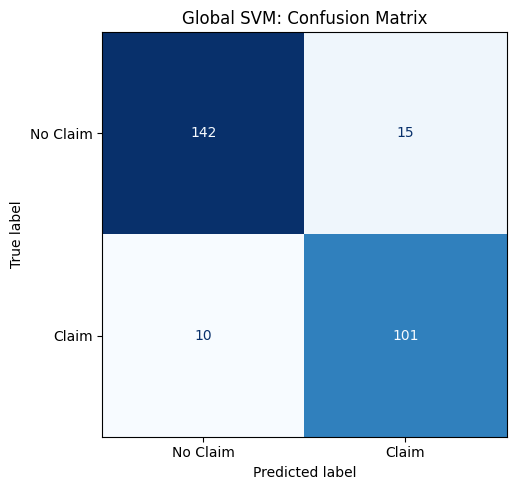

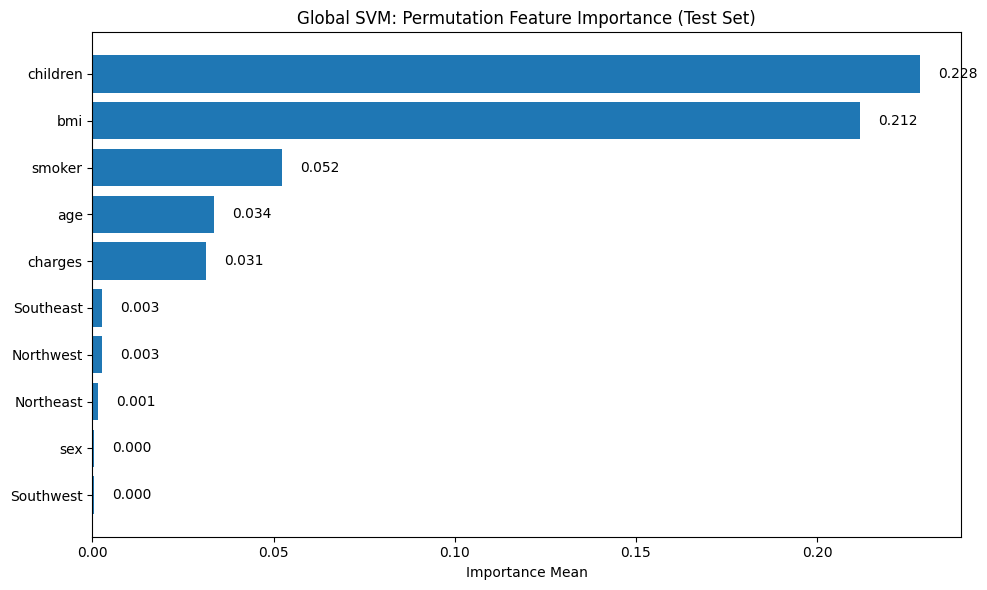

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance
import numpy as np # Ensure numpy is imported for array operations
import matplotlib.pyplot as plt # Ensure matplotlib is imported

# Helper function to clean feature names and filter out 'remainder__' features
def get_cleaned_feature_importance_data(original_feature_names, importance_means):
    # Mapping for common feature prefixes and specific OHE outputs
    cleaned_names = []
    cleaned_importances = []

    # Ensure original_feature_names and importance_means are aligned before filtering
    if len(original_feature_names) != len(importance_means):
        raise ValueError("Length of original_feature_names and importance_means must be the same.")

    for i, name in enumerate(original_feature_names):
        # Exclude 'remainder__' features as requested
        if name.startswith('remainder__'):
            continue

        # Apply specific mappings based on user request and transformer output
        display_name = name
        if name == 'num__children':
            display_name = 'children'
        elif name == 'num__charges':
            display_name = 'charges'
        elif name == 'num__age':
            display_name = 'age'
        elif name == 'num__bmi':
            display_name = 'bmi'
        elif name == 'ord__smoker': # For cluster models
            display_name = 'smoker'
        elif name == 'ord__sex': # For cluster models
            display_name = 'sex'
        elif name == 'cat__sex_Male': # For global model
            display_name = 'sex'
        elif name == 'cat__smoker_Smoking': # For global model
            display_name = 'smoker'
        elif name == 'cat__region_Northeast' or name == 'ohe__region_0':
            display_name = 'Northeast'
        elif name == 'cat__region_Northwest' or name == 'ohe__region_1':
            display_name = 'Northwest'
        elif name == 'cat__region_Southeast' or name == 'ohe__region_2':
            display_name = 'Southeast'
        elif name == 'cat__region_Southwest' or name == 'ohe__region_3':
            display_name = 'Southwest'
        # Fallback for any other 'num__' or 'ord__' if not caught above
        elif name.startswith('num__'):
            display_name = name.replace('num__', '')
        elif name.startswith('ord__'):
            display_name = name.replace('ord__', '')

        cleaned_names.append(display_name)
        cleaned_importances.append(importance_means[i])

    # Convert to numpy arrays for sorting
    cleaned_names = np.array(cleaned_names)
    cleaned_importances = np.array(cleaned_importances)

    # Sort based on importance means
    sorted_idx = cleaned_importances.argsort()

    return cleaned_names[sorted_idx], cleaned_importances[sorted_idx]

# --- Global SVM Model ---
print("### Global SVM Model ###")

# Re-create and train the global SVM pipeline
# (from additional_global_models in cell 3ede7563)
global_svm_model = additional_global_models['SVM']

global_svm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', global_svm_model)
])

# Fit on global train data
global_svm_pipeline.fit(X_train, y_train)

# Predictions for Confusion Matrix
y_pred_global_svm = global_svm_pipeline.predict(X_test)

# Plot Confusion Matrix
fig_cm_global = plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_global_svm,
    display_labels=['No Claim', 'Claim'],
    cmap=plt.cm.Blues,
    colorbar=False,
    ax=plt.gca()
)
plt.title('Global SVM: Confusion Matrix')
plt.tight_layout()
plt.show()

# Feature Importance using Permutation Importance for Global SVM
# 1. Transform X_test using the pipeline's preprocessor
X_test_transformed = global_svm_pipeline.named_steps['preprocessor'].transform(X_test)

# 2. Get all feature names after preprocessing from the ColumnTransformer
feature_names_transformed = global_svm_pipeline.named_steps['preprocessor'].get_feature_names_out()

# 3. Calculate permutation importance on the classifier using the transformed X_test
result_global_svm = permutation_importance(
    global_svm_pipeline.named_steps['classifier'], # Classifier only
    X_test_transformed, # Transformed data
    y_test,
    n_repeats=10, random_state=42, n_jobs=-1
)

# Clean and sort feature importance data
cleaned_feature_names_global, cleaned_importances_global = get_cleaned_feature_importance_data(
    feature_names_transformed,
    result_global_svm.importances_mean
)

fig_fi_global, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    cleaned_feature_names_global,
    cleaned_importances_global
)
plt.title('Global SVM: Permutation Feature Importance (Test Set)')
plt.xlabel('Importance Mean')

# Add importance values on the bars
for i, (importance, name) in enumerate(zip(cleaned_importances_global, cleaned_feature_names_global)):
    ax.text(importance + 0.005, i, f'{importance:.3f}', va='center') # Adjust 0.005 for spacing

plt.tight_layout()
plt.show()

### Cluster 0 SVM Model ###


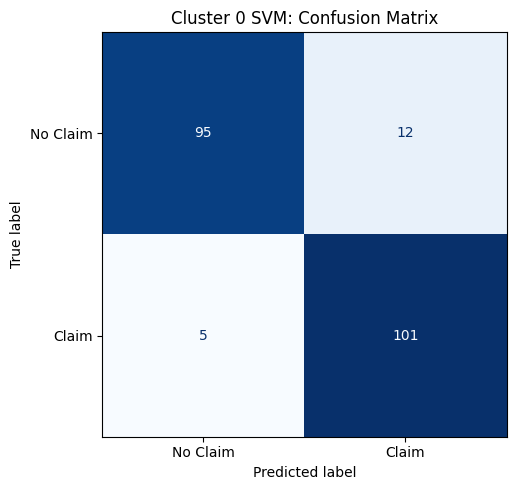

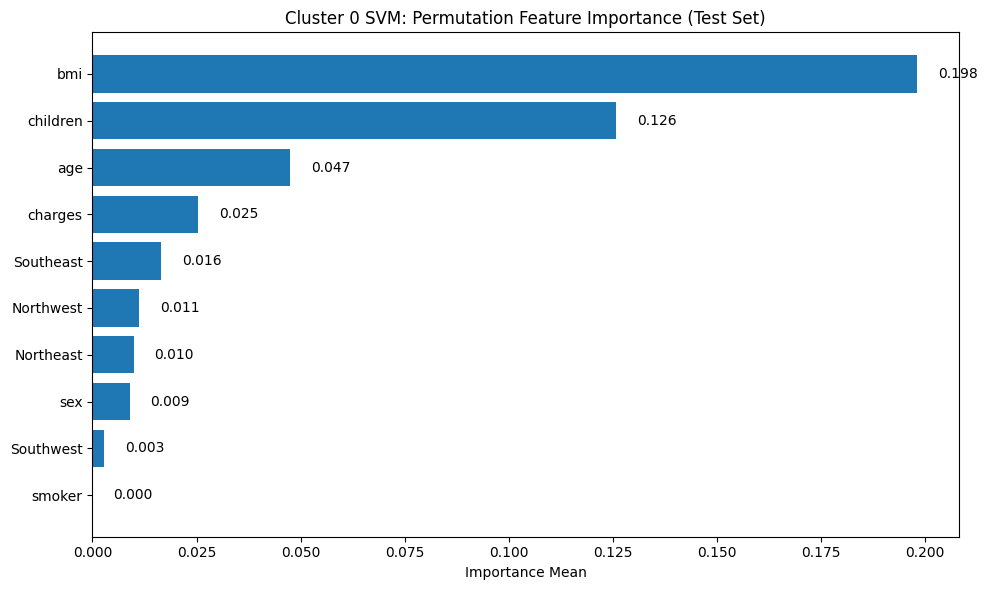

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder # Add OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split # Explicitly import train_test_split
from sklearn.svm import SVC # Explicitly import SVC
import numpy as np # Explicitly import numpy
import matplotlib.pyplot as plt # Explicitly import matplotlib

# --- Cluster 0 SVM Model ---
print("### Cluster 0 SVM Model ###")

# Filter data for Cluster 0
df_cluster0 = df[df['Cluster'] == 0].copy()
X_cluster0 = df_cluster0.drop(['insuranceclaim', 'Cluster'], axis=1)
y_cluster0 = df_cluster0['insuranceclaim']

# Split data for Cluster 0 to get X_test_c0, y_test_c0
X_train_c0, X_test_c0, y_train_c0, y_test_c0 = train_test_split(
    X_cluster0, y_cluster0, test_size=0.2, random_state=42, stratify=y_cluster0
)

# Redefine preprocessor for clusters (consistent with 50286b6f with new encoding strategy)
cluster_numerical_features = ['age', 'bmi', 'children','charges']
cluster_ordinal_features = ['sex', 'smoker']
cluster_onehot_features = ['region']

# Get unique categories for one-hot encoded features (region is int64 in X_cluster)
# Using 'df' (full df) to ensure consistent categories across all models/clusters
region_categories_cluster = sorted(df['region'].unique())

preprocessor_for_clusters = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), cluster_numerical_features),
        ('ord', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cluster_ordinal_features),
        ('ohe', OneHotEncoder(handle_unknown='ignore', drop=None, categories=[region_categories_cluster]), cluster_onehot_features)
    ],
    remainder='passthrough'
)

# Create and train the SVM pipeline for Cluster 0
svm_cluster0_model = SVC(random_state=42, probability=True)
svm_cluster0_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_for_clusters),
    ('classifier', svm_cluster0_model)
])
svm_cluster0_pipeline.fit(X_train_c0, y_train_c0)

# Predictions for Confusion Matrix
y_pred_cluster0_svm = svm_cluster0_pipeline.predict(X_test_c0)

# Plot Confusion Matrix
fig_cm_c0 = plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_c0, y_pred_cluster0_svm,
    display_labels=['No Claim', 'Claim'],
    cmap=plt.cm.Blues,
    colorbar=False,
    ax=plt.gca()
)
plt.title('Cluster 0 SVM: Confusion Matrix')
plt.tight_layout()
plt.show()

# Feature Importance using Permutation Importance for Cluster 0 SVM
# 1. Transform X_test_c0 using the pipeline's preprocessor
X_test_c0_transformed = svm_cluster0_pipeline.named_steps['preprocessor'].transform(X_test_c0)

# 2. Get all feature names after preprocessing from the ColumnTransformer
feature_names_transformed_c0 = svm_cluster0_pipeline.named_steps['preprocessor'].get_feature_names_out()

# 3. Calculate permutation importance on the classifier using the transformed X_test_c0
result_cluster0_svm = permutation_importance(
    svm_cluster0_pipeline.named_steps['classifier'], # Classifier only
    X_test_c0_transformed, # Transformed data
    y_test_c0,
    n_repeats=10, random_state=42, n_jobs=-1
)

# Clean and sort feature importance data using the helper function
cleaned_feature_names_c0, cleaned_importances_c0 = get_cleaned_feature_importance_data(
    feature_names_transformed_c0,
    result_cluster0_svm.importances_mean
)

fig_fi_c0, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    cleaned_feature_names_c0,
    cleaned_importances_c0
)
plt.title('Cluster 0 SVM: Permutation Feature Importance (Test Set)')
plt.xlabel('Importance Mean')

# Add importance values on the bars
for i, (importance, name) in enumerate(zip(cleaned_importances_c0, cleaned_feature_names_c0)):
    ax.text(importance + 0.005, i, f'{importance:.3f}', va='center') # Adjust 0.005 for spacing

plt.tight_layout()
plt.show()

### Cluster 1 SVM Model ###


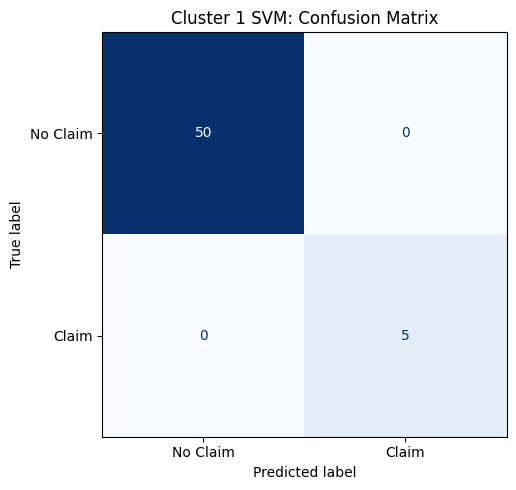

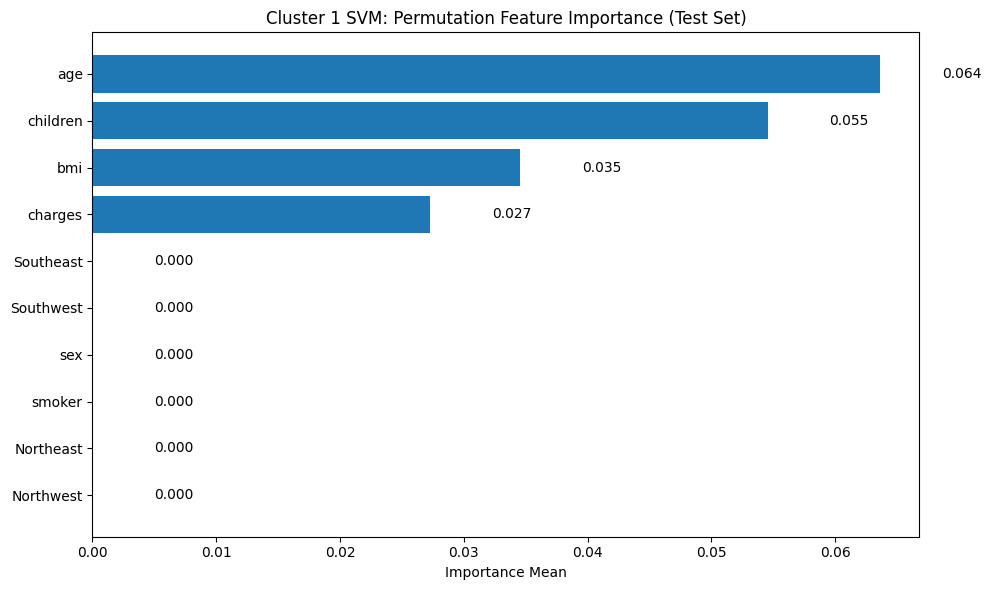

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder # Add OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split # Explicitly import train_test_split
from sklearn.svm import SVC # Explicitly import SVC
import numpy as np # Explicitly import numpy
import matplotlib.pyplot as plt # Explicitly import matplotlib

# --- Cluster 1 SVM Model ---
print("### Cluster 1 SVM Model ###")

# Filter data for Cluster 1
df_cluster1 = df[df['Cluster'] == 1].copy()
X_cluster1 = df_cluster1.drop(['insuranceclaim', 'Cluster'], axis=1)
y_cluster1 = df_cluster1['insuranceclaim']

# Split data for Cluster 1 to get X_test_c1, y_test_c1
X_train_c1, X_test_c1, y_train_c1, y_test_c1 = train_test_split(
    X_cluster1, y_cluster1, test_size=0.2, random_state=42, stratify=y_cluster1
)

# Redefine preprocessor for clusters (consistent with 50286b6f with new encoding strategy)
cluster_numerical_features = ['age', 'bmi', 'children','charges']
cluster_ordinal_features = ['sex', 'smoker']
cluster_onehot_features = ['region']

# Get unique categories for one-hot encoded features (region is int64 in X_cluster)
# Using 'df' (full df) to ensure consistent categories across all models/clusters
region_categories_cluster = sorted(df['region'].unique())

preprocessor_for_clusters = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), cluster_numerical_features),
        ('ord', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cluster_ordinal_features),
        ('ohe', OneHotEncoder(handle_unknown='ignore', drop=None, categories=[region_categories_cluster]), cluster_onehot_features)
    ],
    remainder='passthrough'
)

# Create and train the SVM pipeline for Cluster 1
svm_cluster1_model = SVC(random_state=42, probability=True)
svm_cluster1_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_for_clusters),
    ('classifier', svm_cluster1_model)
])
svm_cluster1_pipeline.fit(X_train_c1, y_train_c1)

# Predictions for Confusion Matrix
y_pred_cluster1_svm = svm_cluster1_pipeline.predict(X_test_c1)

# Plot Confusion Matrix
fig_cm_c1 = plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_c1, y_pred_cluster1_svm,
    display_labels=['No Claim', 'Claim'],
    cmap=plt.cm.Blues,
    colorbar=False,
    ax=plt.gca()
)
plt.title('Cluster 1 SVM: Confusion Matrix')
plt.tight_layout()
plt.show()

# Feature Importance using Permutation Importance for Cluster 1 SVM
# 1. Transform X_test_c1 using the pipeline's preprocessor
X_test_c1_transformed = svm_cluster1_pipeline.named_steps['preprocessor'].transform(X_test_c1)

# 2. Get all feature names after preprocessing from the ColumnTransformer
feature_names_transformed_c1 = svm_cluster1_pipeline.named_steps['preprocessor'].get_feature_names_out()

# 3. Calculate permutation importance on the classifier using the transformed X_test_c1
result_cluster1_svm = permutation_importance(
    svm_cluster1_pipeline.named_steps['classifier'], # Classifier only
    X_test_c1_transformed, # Transformed data
    y_test_c1,
    n_repeats=10, random_state=42, n_jobs=-1
)

# Clean and sort feature importance data using the helper function
cleaned_feature_names_c1, cleaned_importances_c1 = get_cleaned_feature_importance_data(
    feature_names_transformed_c1,
    result_cluster1_svm.importances_mean
)

fig_fi_c1, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    cleaned_feature_names_c1,
    cleaned_importances_c1
)
plt.title('Cluster 1 SVM: Permutation Feature Importance (Test Set)')
plt.xlabel('Importance Mean')

# Add importance values on the bars
for i, (importance, name) in enumerate(zip(cleaned_importances_c1, cleaned_feature_names_c1)):
    ax.text(importance + 0.005, i, f'{importance:.3f}', va='center') # Adjust 0.005 for spacing

plt.tight_layout()
plt.show()

### Linear Kernel SVMs: Feature Importance from Coefficients

Since the default RBF kernel SVMs do not have directly interpretable feature importance coefficients, we will retrain the models with a **linear kernel** (`SVC(kernel='linear')`). For linear SVMs, the absolute value of the coefficients can be used as a measure of feature importance, indicating the strength and direction of a feature's influence on the decision boundary.

### Global SVM Model (Linear Kernel) ###


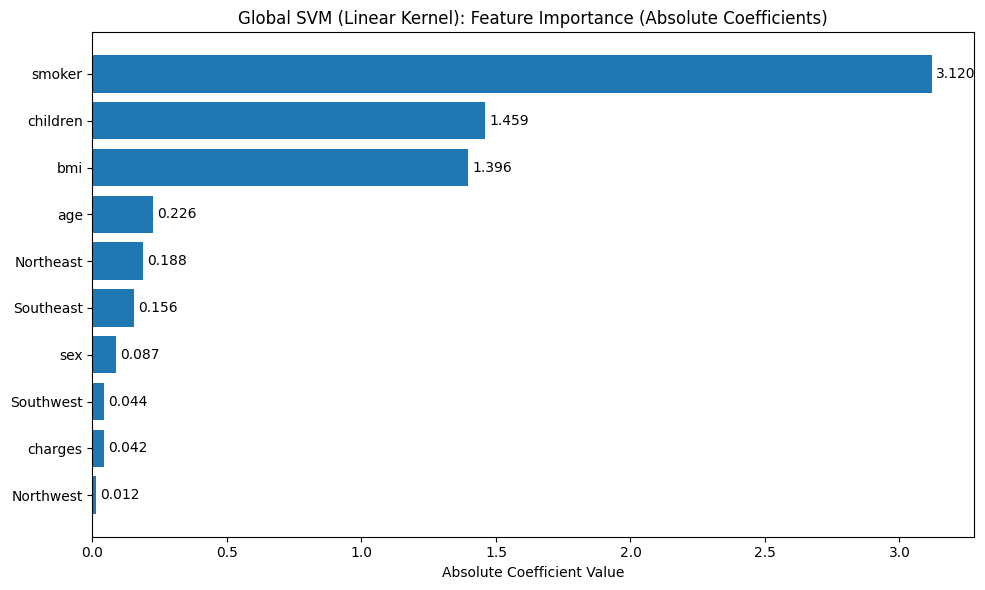

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
import numpy as np
import matplotlib.pyplot as plt

# Helper function to clean feature names and filter out 'remainder__' features
# Adapted for coefficients (can be negative, so we take abs() for plotting importance)
def get_cleaned_coefficient_data(original_feature_names, coefficients):
    cleaned_names = []
    cleaned_importances = []

    if len(original_feature_names) != len(coefficients):
        raise ValueError("Length of original_feature_names and coefficients must be the same.")

    for i, name in enumerate(original_feature_names):
        # Exclude 'remainder__' features
        if name.startswith('remainder__'):
            continue

        display_name = name
        if name == 'num__children':
            display_name = 'children'
        elif name == 'num__charges':
            display_name = 'charges'
        elif name == 'num__age':
            display_name = 'age'
        elif name == 'num__bmi':
            display_name = 'bmi'
        elif name == 'ord__smoker':
            display_name = 'smoker'
        elif name == 'ord__sex':
            display_name = 'sex'
        elif name == 'cat__sex_Male': # For global model
            display_name = 'sex'
        elif name == 'cat__smoker_Smoking': # For global model
            display_name = 'smoker'
        elif name == 'cat__region_Northeast' or name == 'ohe__region_0':
            display_name = 'Northeast'
        elif name == 'cat__region_Northwest' or name == 'ohe__region_1':
            display_name = 'Northwest'
        elif name == 'cat__region_Southeast' or name == 'ohe__region_2':
            display_name = 'Southeast'
        elif name == 'cat__region_Southwest' or name == 'ohe__region_3':
            display_name = 'Southwest'
        elif name.startswith('num__'):
            display_name = name.replace('num__', '')
        elif name.startswith('ord__'):
            display_name = name.replace('ord__', '')

        cleaned_names.append(display_name)
        cleaned_importances.append(abs(coefficients[i])) # Use absolute value for importance

    # Convert to numpy arrays for sorting
    cleaned_names = np.array(cleaned_names)
    cleaned_importances = np.array(cleaned_importances)

    # Sort based on importance values (absolute coefficients)
    sorted_idx = cleaned_importances.argsort()

    return cleaned_names[sorted_idx], cleaned_importances[sorted_idx]

# --- Global SVM Model (Linear Kernel) ---
print("### Global SVM Model (Linear Kernel) ###")

# Re-create and train the global SVM pipeline with a linear kernel
global_svm_linear_model = SVC(kernel='linear', random_state=42)

global_svm_linear_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', global_svm_linear_model)
])

# Fit on global train data
global_svm_linear_pipeline.fit(X_train, y_train)

# Get coefficients (for binary classification, coef_ is (1, n_features))
coefficients_global_svm = global_svm_linear_pipeline.named_steps['classifier'].coef_[0]

# Get feature names after preprocessing
feature_names_transformed_global = global_svm_linear_pipeline.named_steps['preprocessor'].get_feature_names_out()

# Clean and sort feature importance data
cleaned_feature_names_global_linear, cleaned_importances_global_linear = get_cleaned_coefficient_data(
    feature_names_transformed_global,
    coefficients_global_svm
)

fig_fi_global_linear, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    cleaned_feature_names_global_linear,
    cleaned_importances_global_linear
)
plt.title('Global SVM (Linear Kernel): Feature Importance (Absolute Coefficients)')
plt.xlabel('Absolute Coefficient Value')

# Add importance values on the bars
for i, (importance, name) in enumerate(zip(cleaned_importances_global_linear, cleaned_feature_names_global_linear)):
    ax.text(importance + 0.005 * cleaned_importances_global_linear.max(), i, f'{importance:.3f}', va='center') # Adjust spacing dynamically

plt.tight_layout()
plt.show()

### Cluster 0 SVM Model (Linear Kernel) ###


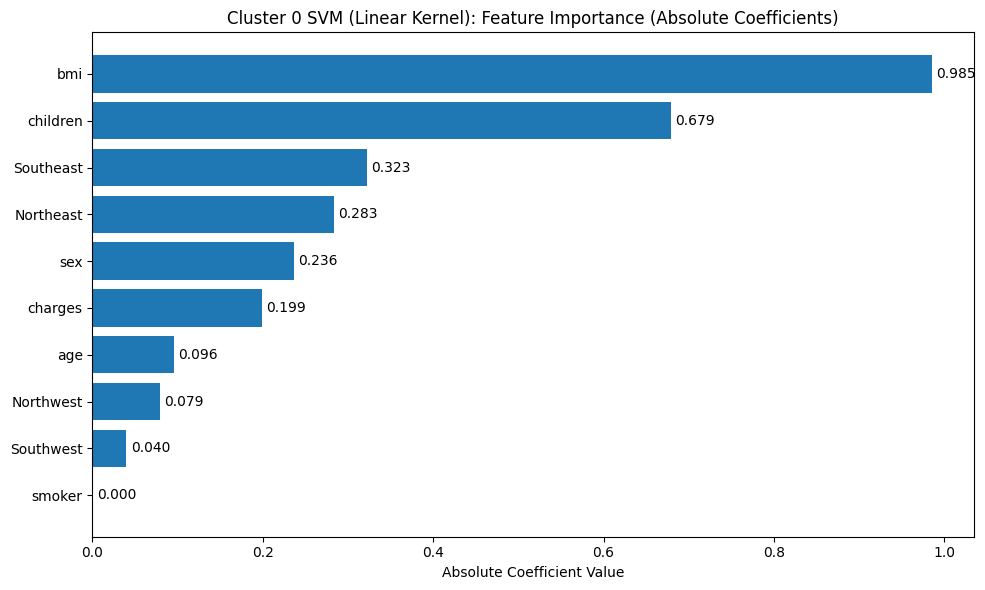

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

# --- Cluster 0 SVM Model (Linear Kernel) ---
print("### Cluster 0 SVM Model (Linear Kernel) ###")

# Filter data for Cluster 0
df_cluster0 = df[df['Cluster'] == 0].copy()
X_cluster0 = df_cluster0.drop(['insuranceclaim', 'Cluster'], axis=1)
y_cluster0 = df_cluster0['insuranceclaim']

# Split data for Cluster 0 to get X_test_c0, y_test_c0
X_train_c0, X_test_c0, y_train_c0, y_test_c0 = train_test_split(
    X_cluster0, y_cluster0, test_size=0.2, random_state=42, stratify=y_cluster0
)

# Redefine preprocessor for clusters (consistent with 50286b6f with new encoding strategy)
# (Ensure preprocessor_for_clusters is defined as in previous cells)
cluster_numerical_features = ['age', 'bmi', 'children','charges']
cluster_ordinal_features = ['sex', 'smoker']
cluster_onehot_features = ['region']
region_categories_cluster = sorted(df['region'].unique())

from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer

preprocessor_for_clusters = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), cluster_numerical_features),
        ('ord', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cluster_ordinal_features),
        ('ohe', OneHotEncoder(handle_unknown='ignore', drop=None, categories=[region_categories_cluster]), cluster_onehot_features)
    ],
    remainder='passthrough'
)

# Create and train the SVM pipeline for Cluster 0 with a linear kernel
svm_cluster0_linear_model = SVC(kernel='linear', random_state=42)
svm_cluster0_linear_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_for_clusters),
    ('classifier', svm_cluster0_linear_model)
])
svm_cluster0_linear_pipeline.fit(X_train_c0, y_train_c0)

# Get coefficients
coefficients_cluster0_svm = svm_cluster0_linear_pipeline.named_steps['classifier'].coef_[0]

# Get feature names after preprocessing
feature_names_transformed_c0_linear = svm_cluster0_linear_pipeline.named_steps['preprocessor'].get_feature_names_out()

# Clean and sort feature importance data
cleaned_feature_names_c0_linear, cleaned_importances_c0_linear = get_cleaned_coefficient_data(
    feature_names_transformed_c0_linear,
    coefficients_cluster0_svm
)

fig_fi_c0_linear, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    cleaned_feature_names_c0_linear,
    cleaned_importances_c0_linear
)
plt.title('Cluster 0 SVM (Linear Kernel): Feature Importance (Absolute Coefficients)')
plt.xlabel('Absolute Coefficient Value')

# Add importance values on the bars
for i, (importance, name) in enumerate(zip(cleaned_importances_c0_linear, cleaned_feature_names_c0_linear)):
    ax.text(importance + 0.005 * cleaned_importances_c0_linear.max(), i, f'{importance:.3f}', va='center')

plt.tight_layout()
plt.show()

### Cluster 1 SVM Model (Linear Kernel) ###


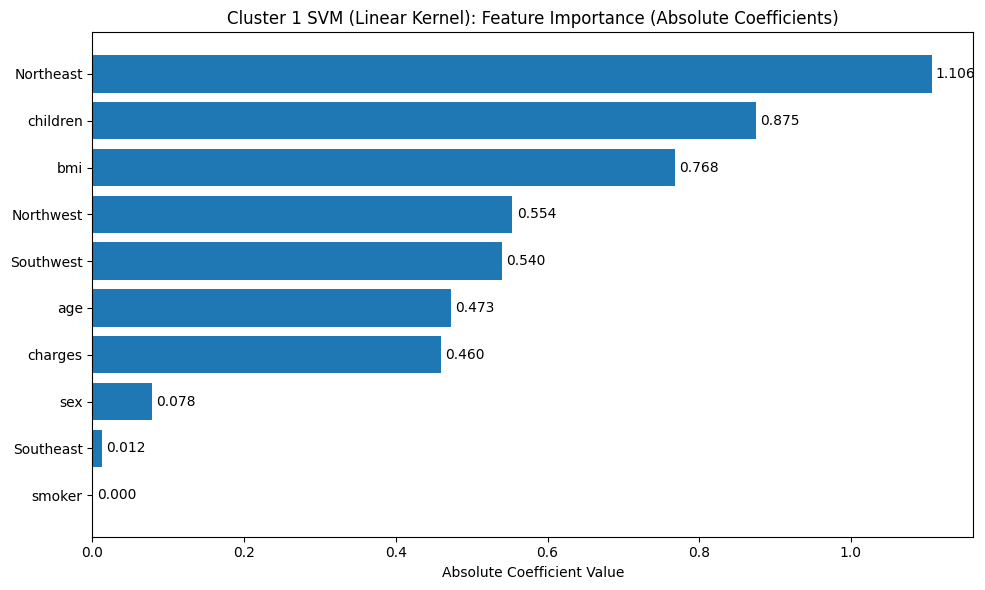

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

# --- Cluster 1 SVM Model (Linear Kernel) ---
print("### Cluster 1 SVM Model (Linear Kernel) ###")

# Filter data for Cluster 1
df_cluster1 = df[df['Cluster'] == 1].copy()
X_cluster1 = df_cluster1.drop(['insuranceclaim', 'Cluster'], axis=1)
y_cluster1 = df_cluster1['insuranceclaim']

# Split data for Cluster 1 to get X_test_c1, y_test_c1
X_train_c1, X_test_c1, y_train_c1, y_test_c1 = train_test_split(
    X_cluster1, y_cluster1, test_size=0.2, random_state=42, stratify=y_cluster1
)

# Redefine preprocessor for clusters (consistent with 50286b6f with new encoding strategy)
# (Ensure preprocessor_for_clusters is defined as in previous cells)
cluster_numerical_features = ['age', 'bmi', 'children','charges']
cluster_ordinal_features = ['sex', 'smoker']
cluster_onehot_features = ['region']
region_categories_cluster = sorted(df['region'].unique())

from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer

preprocessor_for_clusters = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), cluster_numerical_features),
        ('ord', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cluster_ordinal_features),
        ('ohe', OneHotEncoder(handle_unknown='ignore', drop=None, categories=[region_categories_cluster]), cluster_onehot_features)
    ],
    remainder='passthrough'
)

# Create and train the SVM pipeline for Cluster 1 with a linear kernel
svm_cluster1_linear_model = SVC(kernel='linear', random_state=42)
svm_cluster1_linear_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_for_clusters),
    ('classifier', svm_cluster1_linear_model)
])
svm_cluster1_linear_pipeline.fit(X_train_c1, y_train_c1)

# Get coefficients
coefficients_cluster1_svm = svm_cluster1_linear_pipeline.named_steps['classifier'].coef_[0]

# Get feature names after preprocessing
feature_names_transformed_c1_linear = svm_cluster1_linear_pipeline.named_steps['preprocessor'].get_feature_names_out()

# Clean and sort feature importance data
cleaned_feature_names_c1_linear, cleaned_importances_c1_linear = get_cleaned_coefficient_data(
    feature_names_transformed_c1_linear,
    coefficients_cluster1_svm
)

fig_fi_c1_linear, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    cleaned_feature_names_c1_linear,
    cleaned_importances_c1_linear
)
plt.title('Cluster 1 SVM (Linear Kernel): Feature Importance (Absolute Coefficients)')
plt.xlabel('Absolute Coefficient Value')

# Add importance values on the bars
for i, (importance, name) in enumerate(zip(cleaned_importances_c1_linear, cleaned_feature_names_c1_linear)):
    ax.text(importance + 0.005 * cleaned_importances_c1_linear.max(), i, f'{importance:.3f}', va='center')

plt.tight_layout()
plt.show()